# Assignment 1

    Name: Sam Schilder
    Student #: s1154839

# Lecture 1 — Introduction: JAX primer

This assignment introduces JAX, the numerical computing library used throughout the course.

**Learning objectives:**
- Use `jax.random.keys`, `jax.grad`, `jax.vmap`, `jax.jit`, and `jax.lax.scan`
- Understand why JAX enables fast scientific computing

In [5]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

## Demonstration of random keys

In JAX, keys are used to generate random numbers. It is important to manage keys correctly, as it helps with reproducing results, but if done wrong you can be sampling the same random numbers. As we see in the codeblock below, different keys produce different samples, but using `key0` twice results in identical samples.

In [6]:
key0 = jr.PRNGKey(0)
key1 = jr.PRNGKey(1)

print(jr.normal(key0), jr.normal(key1), jr.normal(key0))

1.6226422 -0.15443718 1.6226422


To generate new keys (that are not using a fixed seed), we can use two functions: `jax.random.split` and `jax.random.fold_in`. The first creates multiple new keys from a single key, while the latter generates one new key given an index. These are structured ways to make new keys in for-loops for example.

In [7]:
key2, key3 = jr.split(key1)
key4 = jr.fold_in(key1, 100)

print(jr.normal(key1), jr.normal(key2), jr.normal(key3), jr.normal(key4))

-0.15443718 0.53193736 -0.24392003 0.3732465


We can also generate multiple samples using one key. Notice how it gives the same samples on the same indices.

In [8]:
print(jr.normal(key1), jr.normal(key1, shape=(3,)), jr.normal(key1, shape=(5,)))

-0.15443718 [-0.15443718  0.08470728 -0.13598049] [-0.15443718  0.08470728 -0.13598049 -0.15503626  1.2666674 ]


## Exercise 1: `jax.vmap` for vectorization

Use two `jax.vmap` calls to compute the mean squared difference between `x` and `y` over the last dimension (with shape 30), and sum this difference over the second dimension of x (with shape 5). The result should be an array of shape (10,).

In [31]:
key = jr.PRNGKey(0)
key1, key2 = jr.split(key)

x = jr.normal(key1, shape=(10, 5, 30))
y = jr.normal(key2, shape=(10, 30))

def msd(a1, a2):
    return jnp.mean((a1 - a2)**2)  # calculate mean square difference
def sumdiff(b1, b2):
    diff = f1(b1, b2)
    return jnp.sum(diff)  # sum difference

f1 = jax.vmap(msd, in_axes=(0, None))
f2 = jax.vmap(sumdiff, in_axes=(0, 0))


output = f2(x, y)

print(output, output.shape)

[12.569165 11.026242 10.319008  8.24042   7.929291 10.346539  9.026328
 15.571631  8.460735 12.148213] (10,)


## Exercise 2: Automatic differentiation

Consider the function $f(x) = x^3 - \cos(x)$.

**1a.** Derive the analytical derivative $f'(x)$ by hand.

**Answer:** $f'(x) = 3x^2 + \sin(x)$.

**1b.** Use `jax.grad` to compute $f'$ automatically and verify it matches the analytical result.
Use `jax.vmap` to evaluate both over $x \in [-2, 2]$ and plot them.

<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
C:\Users\samsc\AppData\Local\Temp\ipykernel_3408\1900892300.py:11: SyntaxWarning: invalid escape sequence '\c'
  axes[0].plot(x, y, label='f(x) = $x^3 - \cos(x)$')


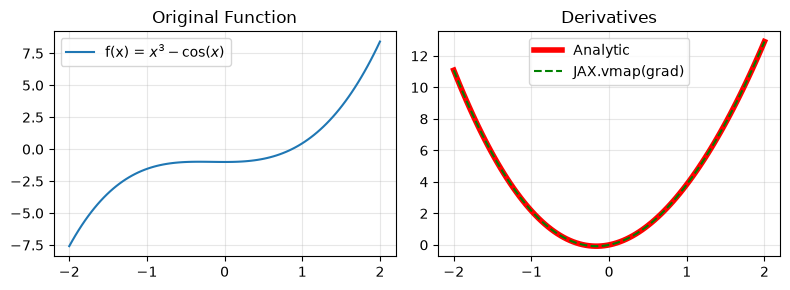

Max absolute error: 0.00e+00


In [50]:
f = lambda x: x**3 - jnp.cos(x)
df_analytic = lambda x: 3*x**2 + jnp.sin(x)
df_auto = jax.grad(f)

x = jnp.linspace(-2, 2, 100)
y  = f(x)
dy_a = df_analytic(x)
dy_j = jax.vmap(df_auto)(x)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(x, y, label='f(x) = $x^3 - \cos(x)$')
axes[0].set_title('Function')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, dy_a, label='Analytic derivative', color='red', linewidth=4)
axes[1].plot(x, dy_j, label='JAX.vmap(grad) derivative', color='green', linestyle='--')
axes[1].set_title('Derivatives')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Max absolute error: {float(jnp.max(jnp.abs(dy_a-dy_j))):.2e}')

## Exercise 3: `jax.lax.scan` for Fibonacci and speedup

**3a.** Use `jax.lax.scan` to compute the first 20 Fibonacci numbers.

In [55]:
# 3a: Fibonacci
def fib_step(carry, _):
    a, b = carry
    c = a+b
    output = a
    a=b
    b=c
    carry = a, b
    return carry, output

carry = 0, 1

_, fibs = jax.lax.scan(fib_step, carry, xs=jnp.arange(20)) #Apply scan here
print('Fibonacci:', fibs)

Fibonacci: [   0    1    1    2    3    5    8   13   21   34   55   89  144  233
  377  610  987 1597 2584 4181]


**3b.** Time a JIT-compiled vs non-compiled version of `euler_scan` above for $10^4$ steps
and report the speedup. What accounts for the difference?

In [63]:
# 3b: speedup
# You can use Fibonacci instead of Euler step in exercise 3b to time the difference between JIT and non-JIT.

import time
dt = 0.001; ts = jnp.arange(0, 10.0, dt)   # 10000 steps

def fib_scan():
    carry = 0, 1

    def fib_step(carry, _):
        a, b = carry
        c = a+b
        output = a
        a=b
        b=c
        carry = a, b
        return carry, output

    _, fibs = jax.lax.scan(fib_step, carry, xs=ts)
    return fibs

def fib_nojit():
    output = []
    carry = 0, 1

    for i in ts:
        a, b = carry
        c = a + b
        output.append(a)
        a=b
        b=c
        carry = a, b

    return output

fib_jit = jax.jit(fib_scan)   # capture lam in closure

fib_jit().block_until_ready()  # warm up
t0=time.perf_counter(); [fib_jit().block_until_ready() for _ in range(50)]; tjit=(time.perf_counter()-t0)/50
t0=time.perf_counter(); [fib_nojit() for _ in range(50)]; tpy=(time.perf_counter()-t0)/50
print(f'JIT: {tjit*1e3:.2f}ms   Python loop: {tpy*1e3:.2f}ms   speedup: {tpy/tjit:.1f}x')

print(f"For this code, JIT does not appear to run much faster than Python 'for' loops.")

JIT: 55.52ms   Python loop: 61.65ms   speedup: 1.1x


## Exercise 4: Conway's Game of Life

Conway's Game of Life is a discrete dynamical system that simulates the evolution of states that can be on or off, and change depending on their neighbours. Simulate Conway's Game of Life in JAX. Try to make your solution as efficient as possible in terms of JAX functionality. One function that can be used for this is `jax.scipy.signal.convolve2d`, but this is not the only approach.

The rules on Conway's Game of Life:

Initialize a two-dimensional grid with cells that are on or off (alive of dead). At every time step, determine the next state of each cell with the following rules:

+ Any live cell with fewer than two live neighbours dies, as if by underpopulation.
+ Any live cell with two or three live neighbours lives on to the next generation.
+ Any live cell with more than three live neighbours dies, as if by overpopulation.
+ Any dead cell with exactly three live neighbours becomes a live cell, as if by reproduction.

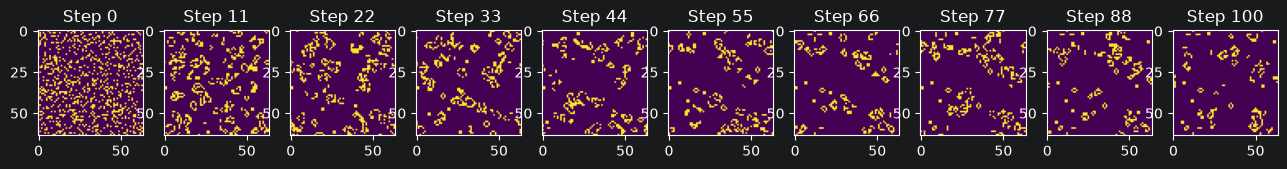

In [81]:
from jax.scipy.signal import convolve2d

def conway_step(state):
    """
    Perform one step of Conway's Game of Life.
    state: 2D jnp.array of 0s and 1s
    Returns: next state (2D jnp.array)
    """
    # Count neighbors using convolution
    kernel = jnp.array([[1,1,1],
                        [1,0,1],
                        [1,1,1]])

    state_padded = jnp.pad(state, pad_width=1, mode='wrap')
    neighbors = convolve2d(state_padded, kernel, mode='valid')

    # rules
    reproduction = (state == 0) & (neighbors == 3)
    survive = (state == 1) & ((neighbors == 2) | (neighbors == 3))

    state = (reproduction | survive)
    return state

# Example usage:
N = 64
init_state = jax.random.bernoulli(jr.PRNGKey(42), p=0.2, shape=(N, N))
T = 100

def run_conway(init_state, T):
    def step(state, _):
        # Write scan function
        state = conway_step(state)
        return state, state
    _, states = jax.lax.scan(step, init_state, xs=jnp.arange(T)) # apply scan
    return jnp.vstack([init_state[None, ...], states])

states = run_conway(init_state, T)

# Plot the evolution
fig, axes = plt.subplots(1, 10, figsize=(16, 8))
time_points = jnp.linspace(0, states.shape[0] - 1, 10, dtype=int)

for ax, t in zip(axes, time_points):
    board = states[t]
    ax.imshow(board)

    ax.set_title(f'Step {t}')
plt.show()
